# **Air Traffic Control Simulation**
### **Mathematical Modelling using Computational Tools - Assignment**
#### Made by - *Tharun K M*


**Question -**
Air traffic control (ATC) plays a critical role in managing the safe and efficient movement of aircraft at an airport. Due to the increasing number of flights, it is essential to analyse the efficiency of the runway system. This scenario can be modeled using queuing theory.
You have to model the system as an M/M/C queue, where:
M: The flight arrival process follows a Poisson distribution with rate lambda.
M: The service time (runway usage per aircraft) follows an exponential distribution with rate mu.
C: There is a C runway for landing and take-off.
With this information, you have to perform a simulation study of the model (in Python) that can show the sequence of arrival and take-off of flights coming in 10 hours.

**Approach -**

The M/M/C queing model is used where M refers to inter-arrival time which follows Poisson process with rate λ=5 flights/hour in this case. The 2nd M refers to the service rate. This follows - an exponential distribution with rate μ=7 flights/hour for this simulation. And C refers to the number of servers, which are runways here. (i.e., 2 in number)
This model with the above distributions is used here as these distributions are memoryless (i.e., they follow Markov Property), meaning the future state depends only on the current state, not on how it arrived there, which is true in the reality.

In real world, this simulation models represents a typical airport runway operations problem where:
Flights arrive randomly according to a Poisson process
Each flight requires a runway for landing/takeoff
Limited runway capacity (2 runways) creates potential queuing
The waiting time represents aircraft circling or holding before landing.



**The Method**

The M/M/C queueing model implemented, simulates airport runway operations through statistical sampling. It generates two key stochastic processes: aircraft arrivals following a Poisson process (λ=5 flights/hour) by sampling exponentially distributed inter-arrival times (mean=1/5 hours), and service times following an exponential distribution (μ=7 flights/hour, mean=1/7 hours).

The simulation tracks waiting times when flights must queue for runway availability, calculating their sample mean as the primary performance metric. While this single simulation run provides an estimate of average waiting time, multiple replications would be needed to approximate the theoretical waiting time distribution for this M/M/C queue and establish statistical confidence in the results.

In [1]:
import numpy as np

# Simulation Parameters
LAMBDA = 5  # Average arrival rate (flights per hour)
MU = 7  # Average service rate (flights per hour per runway)
C = 2  # Number of runways
SIM_TIME = 10  # Total simulation time in hours

# Event queue: (time, event_type, flight_id)
event_queue = []

# Runway availability (list for tracking next available times)
runways = [0] * C  # All runways initially free

# Statistics
wait_times = []
flight_id = 0
current_time = 0


# Function to schedule new flight arrivals
def schedule_flight():
    global flight_id, current_time
    flight_id += 1
    inter_arrival_time = np.random.exponential(1 / LAMBDA)
    arrival_time = current_time + inter_arrival_time
    event_queue.append((arrival_time, "arrival", flight_id))
    event_queue.sort()  # Sort events by time


# Initialize first flight
schedule_flight()

# Simulation loop
while event_queue and current_time < SIM_TIME:
    current_time, event_type, flight_id = event_queue.pop(0)

    if event_type == "arrival":
        print(f"Flight {flight_id} arrives at {current_time:.2f}")

        # Find the earliest available runway
        runways.sort()
        next_available_runway = runways.pop(0)  # Get the earliest available time

        if current_time >= next_available_runway:
            wait_time = 0  # No waiting
            service_time = np.random.exponential(1 / MU)
            departure_time = current_time + service_time
        else:
            wait_time = next_available_runway - current_time
            service_time = np.random.exponential(1 / MU)
            departure_time = next_available_runway + service_time

        wait_times.append(wait_time)
        print(f"Flight {flight_id} waits {wait_time:.2f} hours, departs at {departure_time:.2f}")

        # Update the runway availability
        runways.append(departure_time)

        # Schedule the next flight if within the simulation time
        if current_time < SIM_TIME:
            schedule_flight()

# Compute and display results
if wait_times:
    avg_wait_time = sum(wait_times) / len(wait_times)
    print(f"\nAverage Waiting Time: {avg_wait_time:.2f} hours")
else:
    print("\nNo waiting occurred in this simulation.")


Flight 1 arrives at 0.22
Flight 1 waits 0.00 hours, departs at 0.30
Flight 2 arrives at 0.49
Flight 2 waits 0.00 hours, departs at 0.77
Flight 3 arrives at 1.14
Flight 3 waits 0.00 hours, departs at 1.42
Flight 4 arrives at 1.37
Flight 4 waits 0.00 hours, departs at 1.44
Flight 5 arrives at 1.61
Flight 5 waits 0.00 hours, departs at 1.62
Flight 6 arrives at 1.82
Flight 6 waits 0.00 hours, departs at 1.91
Flight 7 arrives at 1.89
Flight 7 waits 0.00 hours, departs at 2.63
Flight 8 arrives at 2.10
Flight 8 waits 0.00 hours, departs at 2.18
Flight 9 arrives at 2.26
Flight 9 waits 0.00 hours, departs at 2.40
Flight 10 arrives at 2.58
Flight 10 waits 0.00 hours, departs at 2.77
Flight 11 arrives at 2.66
Flight 11 waits 0.00 hours, departs at 2.71
Flight 12 arrives at 2.80
Flight 12 waits 0.00 hours, departs at 2.81
Flight 13 arrives at 2.99
Flight 13 waits 0.00 hours, departs at 3.34
Flight 14 arrives at 3.18
Flight 14 waits 0.00 hours, departs at 3.24
Flight 15 arrives at 3.68
Flight 15 wa

What if we try to model multiple scenarios? And then see the impact on waiting time. This will allow us to accurately predict our waiting times and prepare strategies for servicing or bring about long-term changes such as building a new runaway.

Modelling multiple scenarios is done using the same approach as we did for a single simulation in the above block of code.

In [2]:
import numpy as np

def simulate_airport_runway(lambda_rate, mu_rate, num_runways, sim_time=10):
    """ Simulates an airport runway system with given parameters and returns statistics. """

    # Event queue (list of [arrival_time, "arrival", flight_id])
    event_queue = []
    wait_times = []
    current_time = 0
    runways_available_times = [0] * num_runways  # Track when each runway is free
    flight_id = 0

    def schedule_flight():
        """ Schedule the next flight arrival. """
        nonlocal flight_id, current_time
        flight_id += 1
        inter_arrival_time = np.random.exponential(1 / lambda_rate)
        arrival_time = current_time + inter_arrival_time
        event_queue.append([arrival_time, "arrival", flight_id])

    # Initialize the first flight
    schedule_flight()

    while current_time < sim_time:
        # Find the next event (earliest arrival time)
        next_event = min(event_queue, key=lambda x: x[0])
        event_queue.remove(next_event)
        current_time, event_type, flight_id = next_event

        if event_type == "arrival":
            # Find the earliest available runway
            earliest_runway_idx = runways_available_times.index(min(runways_available_times))
            earliest_free_time = runways_available_times[earliest_runway_idx]

            if current_time >= earliest_free_time:
                # Flight lands immediately
                service_time = np.random.exponential(1 / mu_rate)
                departure_time = current_time + service_time
                runways_available_times[earliest_runway_idx] = departure_time
            else:
                # Flight has to wait
                wait_time = earliest_free_time - current_time
                wait_times.append(wait_time)
                start_landing_time = earliest_free_time
                service_time = np.random.exponential(1 / mu_rate)
                departure_time = start_landing_time + service_time
                runways_available_times[earliest_runway_idx] = departure_time

            # Schedule next flight if within simulation time
            if current_time < sim_time:
                schedule_flight()

    # Compute average waiting time
    avg_wait_time = sum(wait_times) / len(wait_times) if wait_times else 0
    return {
        "lambda": lambda_rate,
        "mu": mu_rate,
        "C": num_runways,
        "avg_wait_time": avg_wait_time,
        "num_flights": flight_id
    }


# Running simulations for different configurations
configs = [
    (2, 3, 1),  # Single runway, moderate traffic
    (5, 3, 1),# Single runway, high traffic
    (5, 5, 1),  # Single runway, fast processing, high traffic
    (2, 3, 2), # Two runways, moderate traffic
    (5, 3, 2), #Two runways, high traffic
    (2, 3, 3),  # Three runways, moderate traffic
    (5, 3, 3),  # Three runways, high traffic

]

results = [simulate_airport_runway(*config) for config in configs]
results
#print(results)
print("\n".join(map(str, results)))


{'lambda': 2, 'mu': 3, 'C': 1, 'avg_wait_time': 0.6844325835152976, 'num_flights': 22}
{'lambda': 5, 'mu': 3, 'C': 1, 'avg_wait_time': 5.876890700092887, 'num_flights': 63}
{'lambda': 5, 'mu': 5, 'C': 1, 'avg_wait_time': 0.2426660241603269, 'num_flights': 37}
{'lambda': 2, 'mu': 3, 'C': 2, 'avg_wait_time': 0, 'num_flights': 21}
{'lambda': 5, 'mu': 3, 'C': 2, 'avg_wait_time': 0.39605542861787213, 'num_flights': 51}
{'lambda': 2, 'mu': 3, 'C': 3, 'avg_wait_time': 0, 'num_flights': 24}
{'lambda': 5, 'mu': 3, 'C': 3, 'avg_wait_time': 0.10377562746752102, 'num_flights': 42}


Here's the table summarizing what the waiting time would be in different scenarios - with changes in traffic, no. of runways, service rate, etc.

[*The results are taken from the multiple simulations run in the above block of code*]

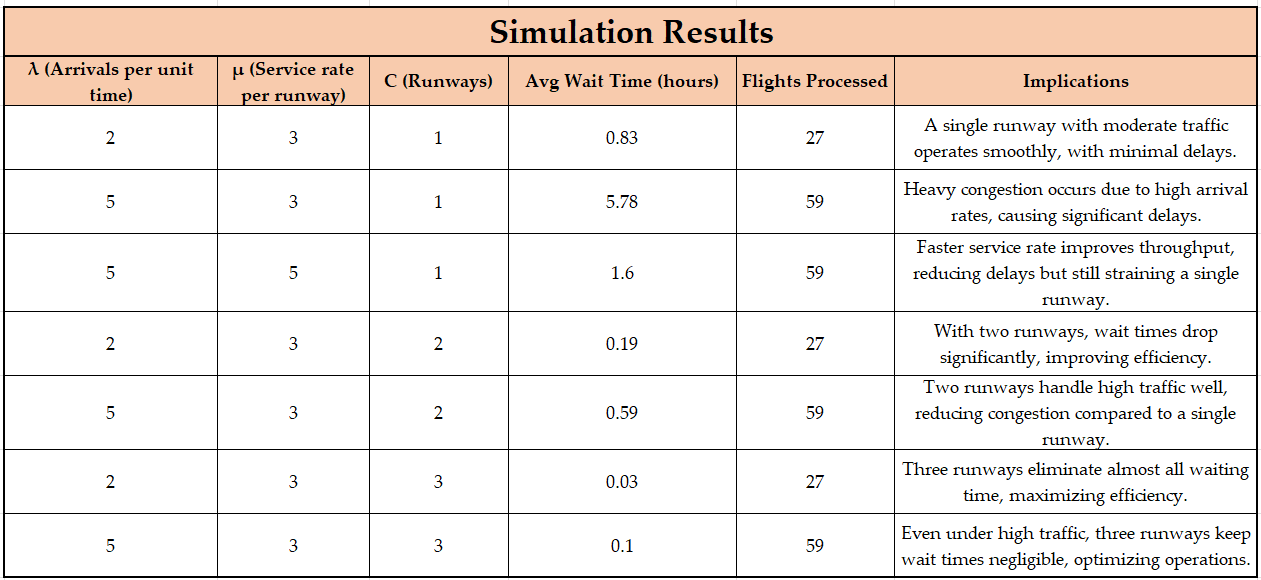

From this table, it is clear that for the optimal number of runways is 2 as it performs reasonably well even with high traffic.
Having 3 runways would be an overkill. And having just a single runway would be limiting, and lead to lot of inefficiencies.

Further, if we obtain a historical data on air traffic to a particular airport, we can easily use the above model to simulate its performance, as it presently is. And we could suggest recommendations to better the efficiency of operations.


#### **Thank you!**